# Research question: “What factors influence how many views a job listing receives?”

I chose to focus on job listing views instead of applications as when exploring the merged dataset, I found that the views column contained significantly fewer missing values compared to the applications column (1689 NaN values for views, 100529 NaN values for application) . This made views a more reliable metric for analysis, allowing for cleaner data processing and more accurate visualizations without needing extensive imputation.

In [1]:
# import libraries
from pathlib import Path

import pandas as pd
import numpy as np

In [2]:
# import csv files
DATA_DIR = Path('datasets')

df1 = pd.read_csv(DATA_DIR / 'postings1.csv', low_memory=False)
df2 = pd.read_csv(DATA_DIR / 'postings2.csv', low_memory=False)
df3 = pd.read_csv(DATA_DIR / 'postings3.csv', low_memory=False)
df4 = pd.read_csv(DATA_DIR / 'postings4.csv', low_memory=False)

## exploring datasets

In [3]:
df1.isnull().sum()

job_id                       0
company_name              1719
title                        0
Easter Egg              115041
Unimportant Column      119672
Easter Egg.1            115041
Unimportant Column.1    119672
Easter Egg.2            115041
Unimportant Column.2    119672
Easter Egg.3            115041
Unimportant Column.3    119672
Easter Egg.4            115041
Unimportant Column.4    119672
Easter Egg.5            115041
Unimportant Column.5    119672
Easter Egg.6            115041
Unimportant Column.6    119672
Easter Egg.7            115041
Unimportant Column.7    119672
Easter Egg.8            115041
Unimportant Column.8    119672
dtype: int64

In [4]:
df2.isnull().sum()

job_id             0
description        7
max_salary     94056
dtype: int64

In [5]:
df3.isnull().sum()

job_id             0
pay_period     87776
location           0
company_id      1717
views           1689
med_salary    117569
min_salary     94056
dtype: int64

In [6]:
df4.isnull().sum()

job_id                             0
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
compensation_type              87776
dtype: int64

## Selecting columns
I selected these columns because they directly relate to understanding what influences the visibility of a job posting. These columns provide meaningful factors that could affect user interest and are essential for exploring what drives higher view counts.

In [7]:
# selecting coloumns
df1_select = df1[['job_id', 'company_name', 'title']]
df2_select = df2[['job_id', 'max_salary']]
df3_select = df3[['job_id', 'pay_period', 'location', 'views', 'med_salary', 'min_salary']]
df4_select = df4[['job_id', 'remote_allowed', 'formatted_experience_level', 'currency']]

## Combining df1-df4

In [8]:
# merge datasets using job_id
# (inner join so only matching job_ids remain)
merged_df = df1_select.merge(df3_select, on="job_id", how="outer").merge(df2_select, on="job_id", how="outer").merge(df4_select, on="job_id", how="outer")

## Create a new column annual_salary
I used a formula to convert hourly, weekly and biweekly salaries into annual salaries. This allows me to accurately compare salaries.

In [9]:
def pick_salary(row):
    # Return min_salary if available, else med_salary, else NaN
    if not pd.isna(row["min_salary"]):
        return row["min_salary"]
    elif not pd.isna(row["med_salary"]):
        return row["med_salary"]
    else:
        return np.nan

def convert_salary(pay_period, salary):
    # pay period conversion formulas.
    if pd.isna(salary) or not isinstance(pay_period, str):
        return np.nan

    if "HOURLY" in pay_period:   # 40 hours per week × 52 weeks per year, 2080
        return salary * 2080
    elif "WEEKLY" in pay_period:  # 52 weeks per year
        return salary * 52
    elif "BIWEEKLY" in pay_period: # 26 pay periods per year, 52/2 =26
        return salary * 26
    elif "MONTHLY" in pay_period:  # 12 months per year
        return salary * 12
    elif "YEARLY" in pay_period:
        return salary

    return np.nan

## Applying lamda
For every row, take the value of the row’s pay period, the chosen salary for that row and feed them into function convert_salary()

In [10]:
merged_df["annual_salary"] = merged_df.apply(
    lambda row: convert_salary(row["pay_period"], pick_salary(row)),
    axis=1
)

## Convert NaN values into 0 for remote_allowed column

In [11]:
merged_df["remote_allowed"] = merged_df["remote_allowed"].fillna(0)

## Converting currency to USD 

In [12]:
merged_df['currency'].unique()

array(['USD', nan, 'CAD', 'BBD', 'EUR', 'AUD', 'GBP'], dtype=object)

In [13]:
exchange_rates = {  # all unique exchange rates  
    'USD': 1,
    'CAD': 0.73,
    'BBD': 0.50,
    'EUR': 1.09,
    'AUD': 0.66,
    'GBP': 1.27
}

merged_df['annual_salary'] = (
    merged_df['annual_salary'] *
    merged_df['currency'].map(exchange_rates)
)


## Making state column

In [14]:
merged_df['state'] = merged_df['location'].str[-2:]  # takes last 2 letters, state codes

In [15]:
merged_df['state'] = merged_df['location'].str[-2:]

# Step 2: valid U.S. states
valid_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',
    'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',
    'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
    'TX','UT','VT','VA','WA','WV','WI','WY'
]

# Step 3: keep only real states
merged_df['state'] = merged_df['state'].where(merged_df['state'].isin(valid_states))

## Inspecting data 

In [16]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   pay_period                  36073 non-null   object 
 4   location                    123849 non-null  object 
 5   views                       122160 non-null  float64
 6   med_salary                  6280 non-null    float64
 7   min_salary                  29793 non-null   float64
 8   max_salary                  29793 non-null   float64
 9   remote_allowed              123849 non-null  float64
 10  formatted_experience_level  94440 non-null   object 
 11  currency                    36073 non-null   object 
 12  annual_salary               36073 non-null   float64
 13  state         

In [17]:
merged_df.describe()

,job_id,views,med_salary,min_salary,max_salary,remote_allowed,annual_salary
count,1.238490e+05,122160.000000,6280.000000,2.979300e+04,2.979300e+04,123849.000000,3.607300e+04
mean,3.896402e+09,14.618247,22015.619876,6.491085e+04,9.193942e+04,0.123102,1.817320e+05
std,8.404355e+07,85.903598,52255.873846,4.959738e+05,7.011101e+05,0.328555,4.662260e+06
min,9.217160e+05,1.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.000000e+00
25%,3.894587e+09,3.000000,18.940000,3.700000e+01,4.828000e+01,0.000000,4.576000e+04
50%,3.901998e+09,4.000000,25.500000,6.000000e+04,8.000000e+04,0.000000,7.000000e+04
75%,3.904707e+09,8.000000,2510.500000,1.000000e+05,1.400000e+05,0.000000,1.050000e+05
max,3.906267e+09,9975.000000,750000.000000,8.500000e+07,1.200000e+08,1.000000,4.992000e+08


In [18]:
merged_df.isnull().sum()

job_id                             0
company_name                    1719
title                              0
pay_period                     87776
location                           0
views                           1689
med_salary                    117569
min_salary                     94056
max_salary                     94056
remote_allowed                     0
formatted_experience_level     29409
currency                       87776
annual_salary                  87776
state                          19753
dtype: int64

In [19]:
merged_df.head(10)

,job_id,company_name,title,pay_period,location,views,med_salary,min_salary,max_salary,remote_allowed,formatted_experience_level,currency,annual_salary,state
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,HOURLY,"Princeton, NJ",20.0,NaN,17.0,20.0,0.0,NaN,USD,35360.0,NJ
1,1218575,Children's Nebraska,Respiratory Therapist,NaN,"Omaha, NE",3.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NE
2,1829192,NaN,Mental Health Therapist/Counselor,HOURLY,"Fort Collins, CO",1.0,NaN,30.0,50.0,0.0,NaN,USD,62400.0,CO
3,2264355,Bay West Church,Worship Leader,MONTHLY,"Palm Bay, FL",5.0,350.0,NaN,NaN,0.0,NaN,USD,4200.0,FL
4,9615617,"Glastender, Inc.",Inside Customer Service Associate,NaN,"Saginaw, MI",4.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,MI
5,10998357,The National Exemplar,Assitant Restaurant Manager,YEARLY,"Cincinnati, OH",8.0,NaN,45000.0,65000.0,0.0,NaN,USD,45000.0,OH
6,11009123,PGAV Destinations,Project Architect,NaN,"St Louis, MO",2.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,MO
7,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,YEARLY,"New Hyde Park, NY",16.0,NaN,140000.0,175000.0,0.0,NaN,USD,140000.0,NY
8,35982263,NaN,Service Technician,YEARLY,"Burlington, IA",3.0,NaN,60000.0,80000.0,0.0,NaN,USD,60000.0,IA
9,56482768,NaN,Appalachian Highlands Women's Business Center,NaN,"Kingsport, TN",2.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,TN


# Data visualisation with matplotlib

In [20]:
import matplotlib.pyplot as plt

## Histogram of the job listings and their annual salaries 
The distribution of annual salaries is highly skewed to the right, indicating that mid-range salary jobs dominate the dataset. Most job listings cluster between `$40,000 and $120,000`, which aligns with the quartile summary of the dataset of median ≈ `$70k`. The steep decline in frequency after $150k shows that high-salary jobs are significantly less common. 

In [21]:
merged_df['annual_salary'].describe()

count    3.607300e+04
mean     1.817320e+05
std      4.662260e+06
min      0.000000e+00
25%      4.576000e+04
50%      7.000000e+04
75%      1.050000e+05
max      4.992000e+08
Name: annual_salary, dtype: float64

In [22]:
# remove extreme outliers
clean_df = merged_df[merged_df["annual_salary"] < 500000]

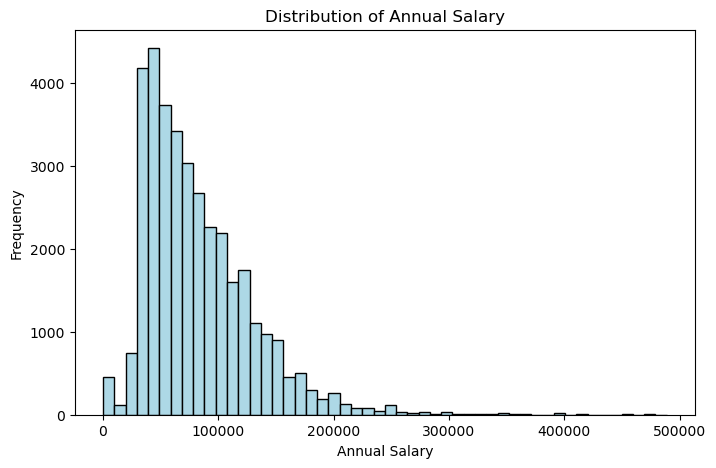

In [23]:
plt.figure(figsize=(8,5))
plt.hist(clean_df["annual_salary"], bins=50, color="lightblue", edgecolor="black")
plt.title("Distribution of Annual Salary")
plt.xlabel("Annual Salary")
plt.ylabel("Frequency")
plt.show()

## Bar chart (Average views of job listing by location)
People may be more interested in viewing jobs located in New York because it is one of the largest economic and employment hubs in the United States. The city offers a wide variety of high-paying roles across industries such as finance, technology, healthcare, and media, which naturally attracts more job seekers. New York also has a strong reputation for career growth, networking opportunities, and access to major companies and headquarters.

Utah is ranked 3rd in Overall Rankings for employment and 1st in Best States Ranking, as a result job listings based in Utah are also likely to draw more interest online, leading to a higher volume of views compared to other states. this suggests that job seekers actively target states with strong economic and employment reputations.

https://www.usnews.com/news/best-states/rankings/economy/employment

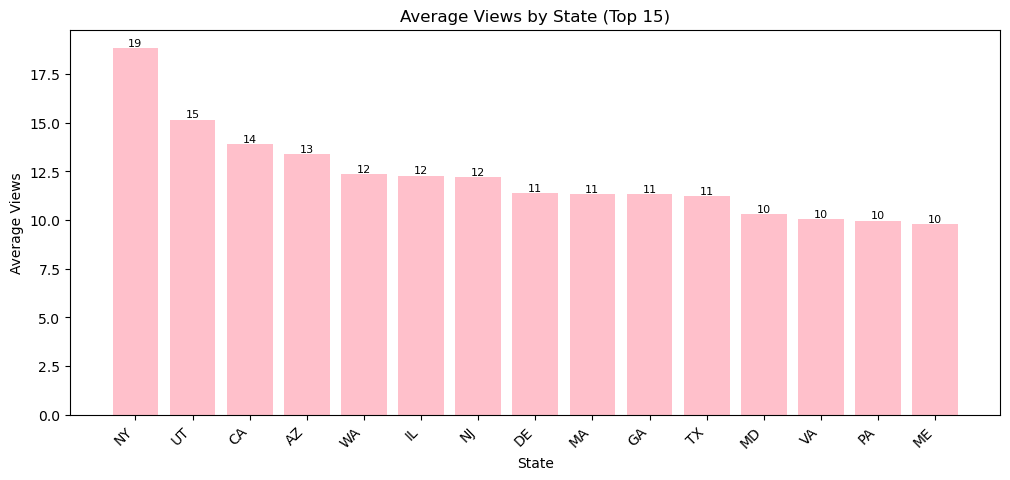

In [31]:
# average number of views for each state, top 15 
location_views = merged_df.groupby("state")["views"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,5))

bars = plt.bar(location_views.index, location_views.values, color = "pink")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # x position (middle of bar)
        height,                              # y position (top of bar)
        f"{height:.0f}",                     # format number
        ha='center', va='bottom', fontsize=8 # alignment + size
    )
plt.title("Average Views by State (Top 15)")
plt.xlabel("State")
plt.ylabel("Average Views")
plt.xticks(rotation=45, ha='right')
plt.show()

## Scatterplot chart (annual salaries and views)
Most job postings fall around the `$40,000 to $150,000` salary range, and these receive the majority of views. The scatterplot shows a large spread of views across all salaries, suggesting that higher pay does not directly translate to more interest. A few high-view jobs exist, but they are not concentrated at the highest salary levels. Overall, salary alone does not seem to be a strong predictor of job listing popularity.

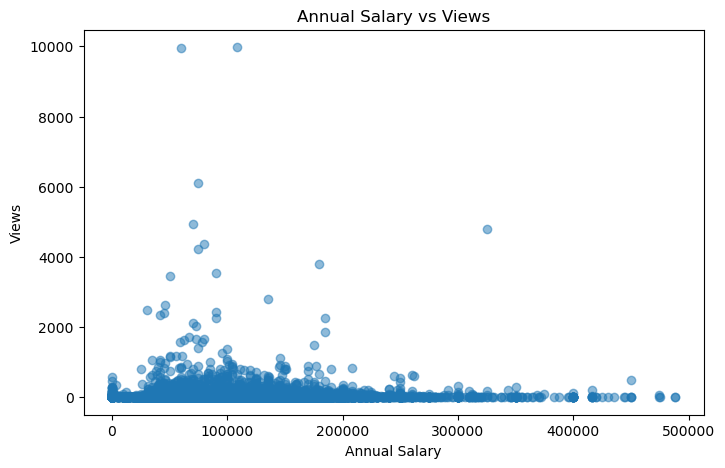

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(clean_df["annual_salary"], clean_df["views"], alpha=0.5)
plt.title("Annual Salary vs Views")
plt.xlabel("Annual Salary")
plt.ylabel("Views")
plt.show()

## Line chart (average views and remote jobs)
Remote job listings receive significantly more views than non-remote listings. This suggests that flexibility and remote work options are strong drivers of job-seeker interest and as remote work becomes more normalized, job postings offering this option appear to attract substantially higher engagement, and thus get more views.

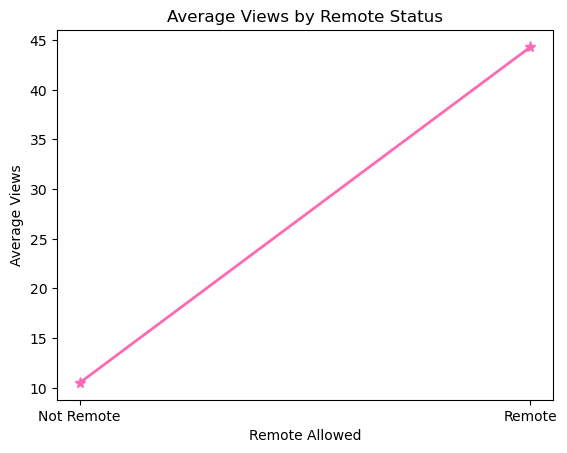

In [26]:
average_views = merged_df.groupby("remote_allowed")["views"].mean()
plt.plot(average_views.index, average_views.values, color = 'hotpink', marker='*', markersize=8, linewidth=2)

plt.title("Average Views by Remote Status")
plt.xlabel("Remote Allowed")
plt.ylabel("Average Views")
plt.xticks([0, 1], ["Not Remote", "Remote"])
plt.show()

## Pie chart (remote allowed)
Even though remote jobs form a smaller share of total job postings, they attract significantly more attention per listing as shown in the line chart. This suggests that remote work is highly appealing to job seekers, leading to disproportionally high engagement despite being a minority of available roles. This highlights a clear trend that job seekers actively prefer and search for remote opportunities.

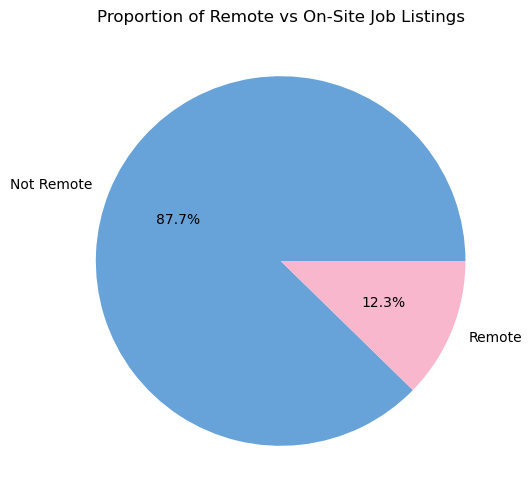

In [27]:
counts = merged_df["remote_allowed"].value_counts()

labels = ["Not Remote", "Remote"]
sizes = [counts.get(0, 0), counts.get(1, 0)]
colors = ["#67A3D9", "#F8B7CD"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors)

plt.title("Proportion of Remote vs On-Site Job Listings")
plt.show()

## Bar chart (average views by job title)
Roles such as “Senior Business Operations Manager” and “Executive Assistant CPO” receive the highest average views, above 4500–5000 views per listing, while other titles such as “Payment Specialist – Work from Home”, “Executive Operations Manager” and “Administrative Specialist – Remote” still attract relatively high but lower views in the 2,500–3,000 range. This suggests that senior leadership, specialised corporate roles and certain remote jobs tend to generate more interest from job seekers compared to other jobs in the dataset.

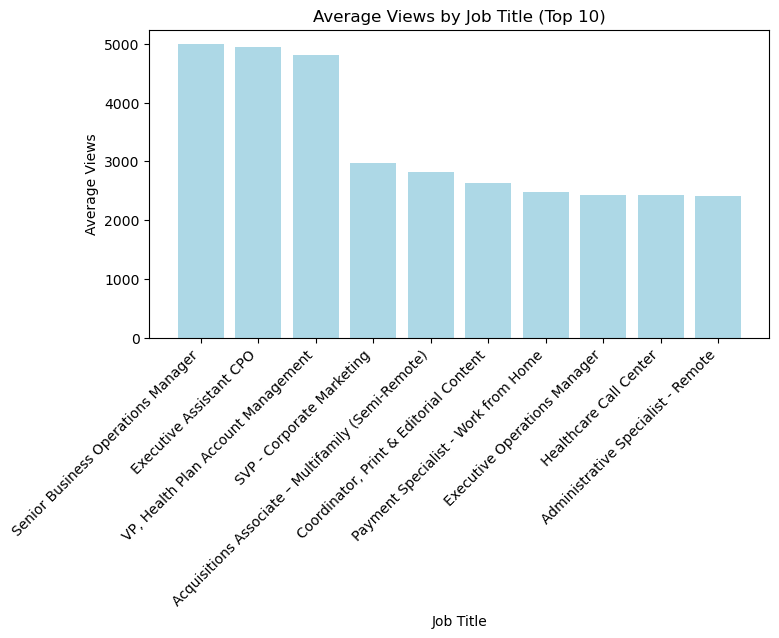

In [28]:
title_views = merged_df.groupby("title")["views"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
plt.bar(title_views.index, title_views.values, color='lightblue')
plt.xticks(rotation=45, ha='right')
plt.title("Average Views by Job Title (Top 10)")
plt.xlabel("Job Title")
plt.ylabel("Average Views")
plt.show()

## Boxplot (views by experience level)
All experience levels show low median view counts, around 4 and 5 views, indicating that job listings generally receive limited attention regardless of experience requirements. However, every category displays a large spread of high view outliers, showing that certain job postings occasionally attract significantly more interest. The similarity in median values suggests that experience level alone is not a strong driver of job listing popularity, and high view jobs appear in every category.

In [29]:
# removes extreme outliers
filtered_df = merged_df[merged_df["views"] < 5000]

<Figure size 1000x600 with 0 Axes>

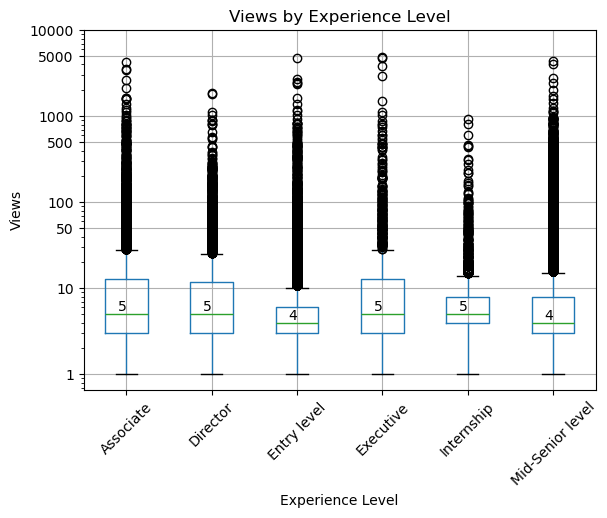

In [30]:
plt.figure(figsize=(10,6))

filtered_df.boxplot(column="views", by="formatted_experience_level")
plt.yscale("log")

ticks = [1, 10, 50, 100, 500, 1000, 5000, 10000]
tick_labels = [str(t) for t in ticks]
plt.xticks(rotation=45, ha='center')
plt.yticks(ticks, tick_labels)
plt.title("Views by Experience Level")
plt.suptitle("")
plt.xlabel("Experience Level")
plt.ylabel("Views")

medians = filtered_df.groupby("formatted_experience_level")["views"].median()
for i, (category, median_val) in enumerate(medians.items(), start=1):
    plt.text(i, median_val,f"{int(median_val)}",ha='right', va='bottom')

plt.show()

## Conclusion
<hr>

In conclusion, my analysis shows that several key factors influence how many views a job listing receives. **Location** plays an important role, with states such as New York, Utah, and California attracting higher average views, likely due to larger job markets, higher population density, and strong economic activity. **Remote job availability** is another major driver; remote positions receive significantly more views than on-site listings, indicating that job seekers strongly prefer flexibility and the ability to work from anywhere.

Although **salary** might seem like an obvious factor, `the results suggest that higher pay does not consistently lead to more views`. Most listings fall within the`$40,000–$150,000` range, and the scatterplot shows no strong relationship between salary and views once extreme outliers are removed. This suggests that job seekers prioritise other features—such as role type or working conditions—over salary alone.

**Job title** has a notable impact as well. Certain specialised or senior positions, such as “Senior Business Operations Manager” and “Executive Assistant CPO,” receive far more views compared to others, likely due to their competitive nature, seniority, or limited availability. However, the experience level analysis indicates that every category,from entry level to executive, tends to receive similarly low median views, suggesting that `experience level alone is not a strong predictor of interest`.

Overall, the findings suggest that `location, remote work flexibility, and specific job roles` are the strongest influencers of job listing visibility, while salary and experience level show weaker or inconsistent effects on view count.